Saving dataset_heart.csv to dataset_heart (4).csv
🔹 Dataset shape: (270, 14)

🔹 First 5 rows:
   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                           

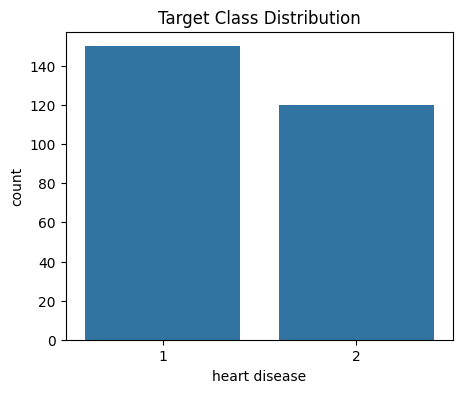

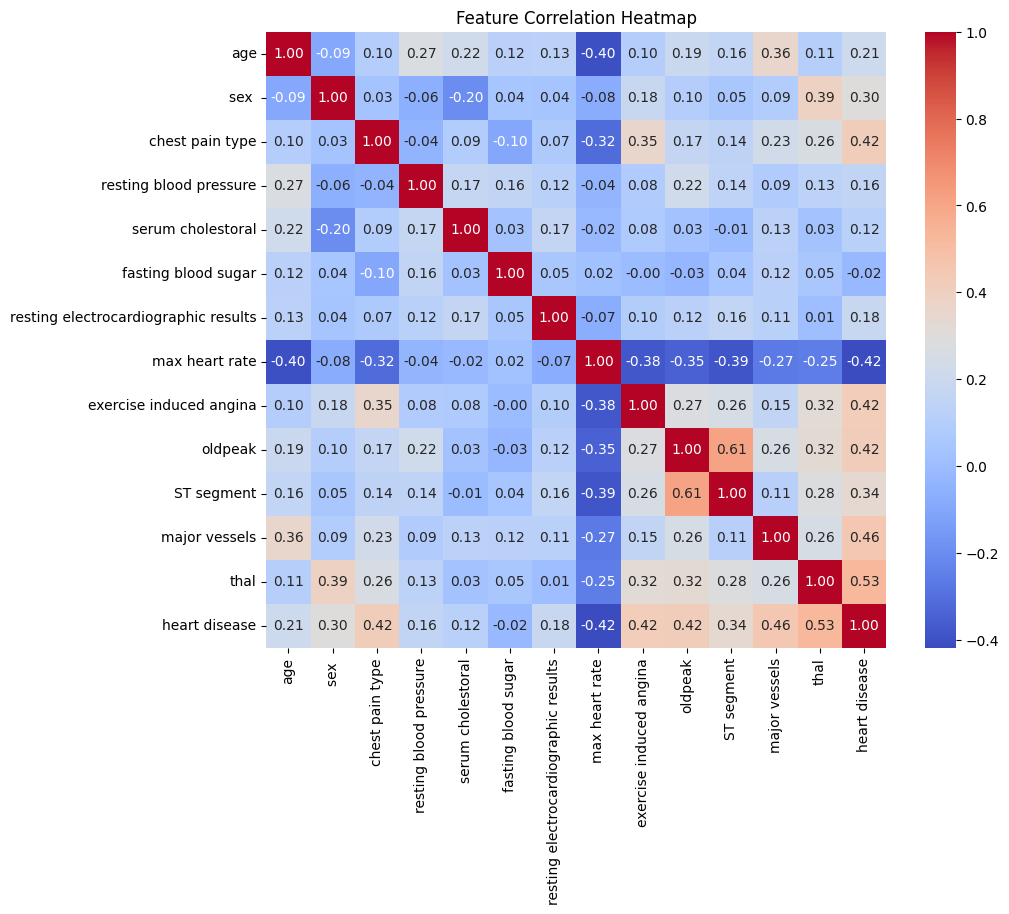

In [6]:
# 🌟 Exercise 1 : Exploratory Data Analysis (EDA)

# Goal: Load, inspect, and understand the dataset.


# Ask user to upload the dataset
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('dataset_heart.csv')

# Basic inspection
print("🔹 Dataset shape:", df.shape)
print("\n🔹 First 5 rows:")
print(df.head())

print("\n🔹 Info:")
print(df.info())

print("\n🔹 Statistical Summary:")
print(df.describe())

# Check for missing values
print("\n🔹 Missing values:")
print(df.isnull().sum())

# Define target column
target_column = 'heart disease'
X = df.drop(columns=[target_column])
y = df[target_column]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n✅ Data successfully split into training and test sets.")
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Visualization: Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()

# Visualization: Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [8]:
# 🌟 Exercise 2 : Logistic Regression (without Grid Search)

# Goal: Build and evaluate a simple logistic regression model.


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize and train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("✅ Logistic Regression (no GridSearch)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Logistic Regression (no GridSearch)
Accuracy: 0.8518518518518519

Confusion Matrix:
 [[24  6]
 [ 2 22]]

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.80      0.86        30
           2       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



In [9]:
# 🌟 Exercise 3 : Logistic Regression (with Grid Search)

# Goal: Optimize hyperparameters using GridSearchCV.


from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Initialize GridSearch
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# Best parameters and model
print("✅ Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluation
y_pred = best_model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Accuracy: 0.8518518518518519

Classification Report:
               precision    recall  f1-score   support

           1       0.89      0.83      0.86        30
           2       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



In [10]:
# 🌟 Exercise 4 : SVM (without Grid Search)
# -------------------------------------------------
# Goal: Train a simple Support Vector Machine classifier.
# -------------------------------------------------

from sklearn.svm import SVC

# Initialize SVM (manual parameters)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# Evaluate
y_pred = svm_model.predict(X_test)
print("✅ SVM (no GridSearch)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ SVM (no GridSearch)
Accuracy: 0.7407407407407407

Confusion Matrix:
 [[26  4]
 [10 14]]

Classification Report:
               precision    recall  f1-score   support

           1       0.72      0.87      0.79        30
           2       0.78      0.58      0.67        24

    accuracy                           0.74        54
   macro avg       0.75      0.73      0.73        54
weighted avg       0.75      0.74      0.73        54



In [12]:
# 🌟 Exercise 5 : SVM (with Grid Search, optimized)

# Goal: Optimize SVM hyperparameters using GridSearchCV (fast version).


from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Reduced parameter grid for faster execution
param_grid = {
    'C': [0.1, 1, 10],          # Regularization strength
    'kernel': ['linear', 'rbf'], # Simplified set of kernels
    'gamma': ['scale']           # Keep default scaling
}

# Initialize GridSearchCV (smaller CV folds for speed)
grid = GridSearchCV(SVC(), param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

# Best model
print("✅ Best Parameters:", grid.best_params_)
best_svm = grid.best_estimator_

# Evaluation
y_pred = best_svm.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
✅ Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Accuracy: 0.8518518518518519

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.80      0.86        30
           2       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



In [15]:
# 🌟 Exercise 6 : XGBoost (without Grid Search)


# Imports
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Remap target {1,2} -> {0,1} for binary classification
# Adjust the mapping if your semantic meaning differs.
y_train_bin = y_train.map({1: 0, 2: 1})
y_test_bin  = y_test.map({1: 0, 2: 1})

# Define and fit XGBoost model (manual parameters)
xgb_model = XGBClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'  # avoids deprecation warnings, sensible for binary
)

xgb_model.fit(X_train, y_train_bin)

# Predict and evaluate
y_pred = xgb_model.predict(X_test)

print("✅ XGBoost (no GridSearch) with remapped labels {1,2} -> {0,1}")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_bin, y_pred))
print("\nClassification Report:\n", classification_report(y_test_bin, y_pred))


✅ XGBoost (no GridSearch) with remapped labels {1,2} -> {0,1}
Accuracy: 0.7962962962962963

Confusion Matrix:
 [[23  7]
 [ 4 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81        30
           1       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54



In [16]:
# 🌟 Exercise 7 : XGBoost (with Grid Search)

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Use the same remapped labels
y_train_bin = y_train.map({1: 0, 2: 1})
y_test_bin  = y_test.map({1: 0, 2: 1})

# Define a compact but effective parameter grid (keeps runtime reasonable)
param_grid = {
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.25]
}

# Initialize base estimator
xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# Grid search (5-fold CV for stability)
grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit on training data (binary labels)
grid.fit(X_train, y_train_bin)

# Report best params and evaluate
print("✅ Best Parameters:", grid.best_params_)
best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test_bin, y_pred))
print("\nClassification Report:\n", classification_report(y_test_bin, y_pred))


Fitting 5 folds for each of 192 candidates, totalling 960 fits
✅ Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}

Accuracy: 0.7962962962962963

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81        30
           1       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54

